Final Project - Part 1 of 3

1) Model Selection

I have chosen Option A: Spring-Mass System:
m*f''(t) + c*f'(t) + k*f(t) = 0

2) Parameter Research

Due to my time in Longhorn Racing, I have chosen parameters that reflect the modeling of an FSAE car suspension

Mass: The mass of a cars suspension system like an FSAE vehicle is usually modeled per wheel (quarter car). Our car here at UT is roughly 452lb, or 205kg. 205kg/4wheels = 51.25kg.

Spring Constant: 150lb/in, or 26270N/m is typical for a slightly lighter car.

Damping Coefficient: From the equation C = 2*b*sqrt(m * k) where b is usually a ratio such as 0.6, c = 1392Ns/m.

Initial Condition: We are going to start the car system on a speed bump of 10in or 0.254m. f(0) = .254, f'(0) = 0, f''(0) = 0.

Source: https://www.fsae.com/forums/archive/index.php/t-10472.html?s=5ce42bd67e1ff12ad0ef134603742939&utm_source=chatgpt.com

3) Numerical Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 51.26
c = 1392
k = 26270

# Base Function
def df(t, x):
    x1, x2 = x
    dx1 = x2
    dx2 = -(c/m)*x2 - (k/m)*x1
    return np.array([dx1, dx2])

In [2]:
# Euler Forward Method
def euler_forward_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros((len(t_values), len(y_0)))
    
    # Set initial conditions
    y_values[0] = y_0
    
    for i in range(1, len(t_values)):
        # Update equations for Euler's Method
        y_values[i] = y_values[i-1] + h * df(t_values[i-1], y_values[i-1])
    
    return t_values, y_values

In [3]:
# Fourth-Order Runge-Kutta Method
def runge_kutta_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros((len(t_values), len(y_0)))
    
    # Set initial conditions
    y_values[0] = y_0
    
    for i in range(1, len(t_values)):
        y = y_values[i-1]
        k1 = df(t_values[i-1], y)
        k2 = df((t + h/2),(y+k1*h/2))
        k3 = df((t + h/2),(y+k2*h/2))
        k4 = df((t + h),(y+k3*h))
        # Update equations for Runge-Kutta Method
        y_values[i] = y_values[i-1] + h*(k1+2*k2+2*k3+k4)/6
        
        return t_values, y_values
    

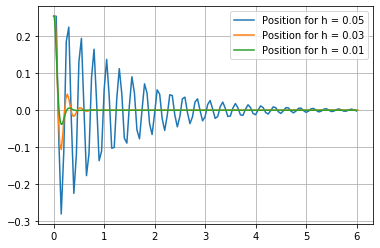

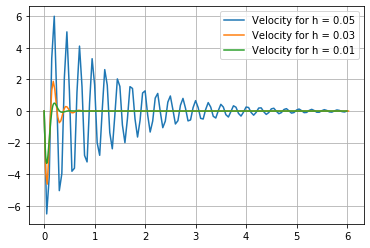

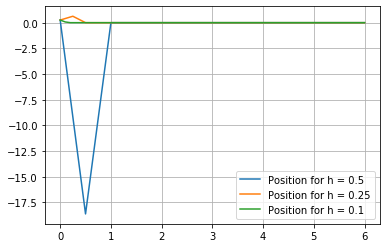

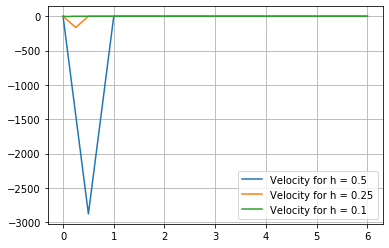

In [5]:
# Test Case
eulerhs = [0.05, 0.03 , 0.01]
rungehs = [.5, .25 , 0.1]
t_start = 0
t_end = 6
y_0 = np.array([.254,0])

# Euler
plt.figure()
for h in eulerhs:
    t, Y = euler_forward_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    plt.plot(t, pos, label='Position for h = ' + str(h))
plt.grid()
plt.legend()
plt.show()

plt.figure()
for h in eulerhs:
    t, Y = euler_forward_method(h, t_start, t_end, y_0)
    vel = Y[:,1]
    plt.plot(t, vel, label='Velocity for h = ' + str(h))
plt.grid()
plt.legend()
plt.show()

# Runge-Kutta
plt.figure()
for h in rungehs:
    t, Y = runge_kutta_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    plt.plot(t, pos, label='Position for h = ' + str(h))
plt.grid()
plt.legend()
plt.show()

plt.figure()
for h in rungehs:
    t, Y = runge_kutta_method(h, t_start, t_end, y_0)
    vel = Y[:,1]
    plt.plot(t, vel, label='Velocity for h = ' + str(h))
plt.grid()
plt.legend()
plt.show()

4) Stability Analysis

In [6]:
# Maximum h Analysis, where max(h) = 2/abs(lambda)
A = np.array([[0,1],[-(k/m),-(c/m)]])
eigvals = np.linalg.eigvals(A)
maxh = 2/max(np.abs(eigvals))
print("The maximum h value is " + str(maxh))

The maximum h value is 0.08834648196461142


In [7]:
# Analytical Solution
b = 0.6
wn = np.sqrt(k/m)
wd = wn*np.sqrt(1-(b*b))
# From initial conditions f(0) = .254 and f'(0) = 0 I can algebraically solve for c1 and c2
c1 = 0.254
c2 = b*wn*c1/wd
def f(t):
    return np.exp(-b*wn*t)*(c1*np.cos(wd*t)+c2*np.sin(wd*t))

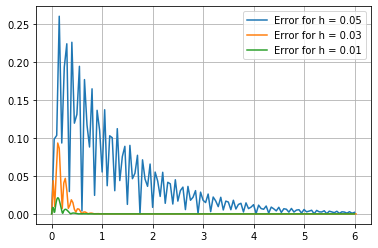

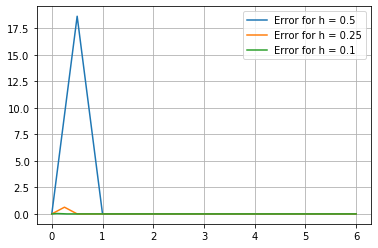

In [8]:
plt.figure()

for h in eulerhs:
    et, Y = euler_forward_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    euler_error = np.abs(pos - f(et))
    plt.plot(et, euler_error, label='Error for h = ' + str(h))
plt.grid()
plt.legend()
plt.show()

for h in rungehs:
    rt, Y = runge_kutta_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    runge_error = np.abs(pos - f(rt))
    plt.plot(rt, runge_error, label='Error for h = ' + str(h))
plt.grid()
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (3,) and (601,)

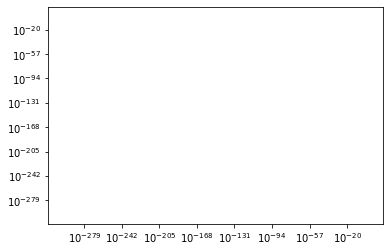

In [9]:
plt.figure()
plt.loglog(eulerhs et, 'o-', label='Euler')
plt.loglog(rungehs, rt, 'o-', label='RK4')

plt.xlabel("Step size (h)")
plt.ylabel("Max error")
plt.title("Error vs Step Size")
plt.legend()
plt.grid()
plt.show()